# Black Friday Sales Analysis

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv("BlackFriday.csv")
df.head(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
5,1000003,P00193542,M,26-35,15,A,3,0,1,2.0,NaN,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,8.0,17.0,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15.0,NaN,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,16.0,NaN,15686
9,1000005,P00274942,M,26-35,20,A,1,1,8,NaN,NaN,7871


In [4]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                           0
dtype: int64

In [5]:
del df["Product_Category_3"]
del df["Product_Category_2"]

In [6]:
df.head(2)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     537577 non-null  int64 
 1   Product_ID                  537577 non-null  object
 2   Gender                      537577 non-null  object
 3   Age                         537577 non-null  object
 4   Occupation                  537577 non-null  int64 
 5   City_Category               537577 non-null  object
 6   Stay_In_Current_City_Years  537577 non-null  object
 7   Marital_Status              537577 non-null  int64 
 8   Product_Category_1          537577 non-null  int64 
 9   Purchase                    537577 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 41.0+ MB


In [8]:
df.nunique()

User_ID                        5891
Product_ID                     3623
Gender                            2
Age                               7
Occupation                       21
City_Category                     3
Stay_In_Current_City_Years        5
Marital_Status                    2
Product_Category_1               18
Purchase                      17959
dtype: int64

## Analysing gender

In [9]:
df.groupby("Gender").size()

Gender
F    132197
M    405380
dtype: int64

In [10]:
Male = len(df[df["Gender"]=="M"]) 
Female = len(df[df["Gender"]=="F"])

gender = pd.DataFrame([Male, Female] ,index=["Male", "Female"])
gender

,0
Male,405380
Female,132197


Text(0.5, 1.0, 'Ratio')

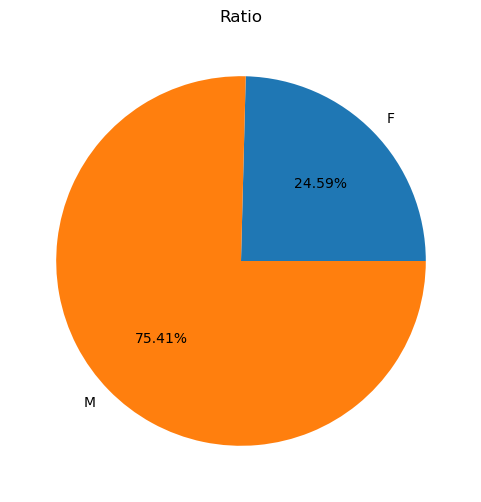

In [11]:
df.groupby("Gender").size().plot( kind="pie", autopct="%.2f%%", figsize=(6,6) )
plt.title("Ratio")

Text(0.5, 1.0, 'Ratio')

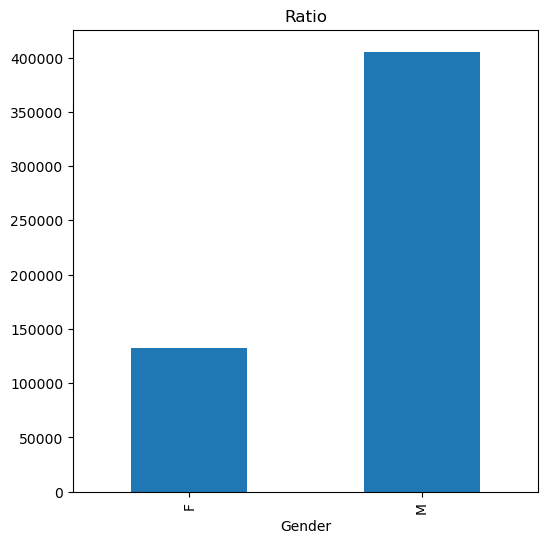

In [12]:
df.groupby("Gender").size().plot( kind="bar",  figsize=(6,6) )
plt.title("Ratio")

<Axes: ylabel='Purchase'>

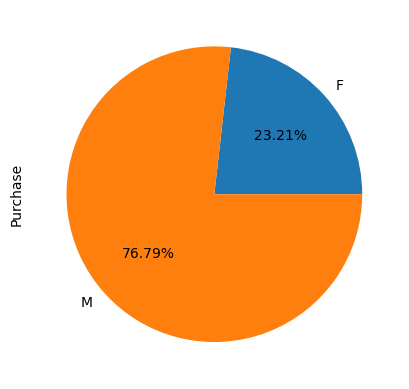

In [13]:
df.groupby("Gender")["Purchase"].sum().plot(kind="pie", autopct="%.2f%%")

<Axes: ylabel='Purchase'>

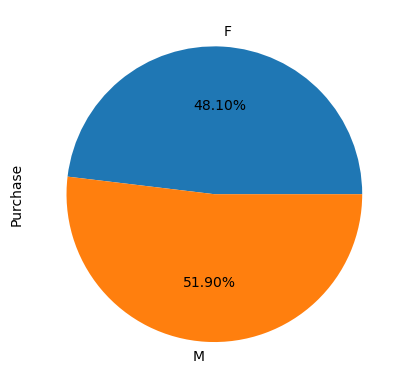

In [14]:
df.groupby("Gender")["Purchase"].mean().plot(kind="pie", autopct="%.2f%%")

In [15]:
df.groupby("Gender")["Purchase"].mean()

Gender
F    8809.761349
M    9504.771713
Name: Purchase, dtype: float64

## Analysing Age and Marrital Status 

<Axes: title={'center': 'Purchase Product Distribution'}, xlabel='Age'>

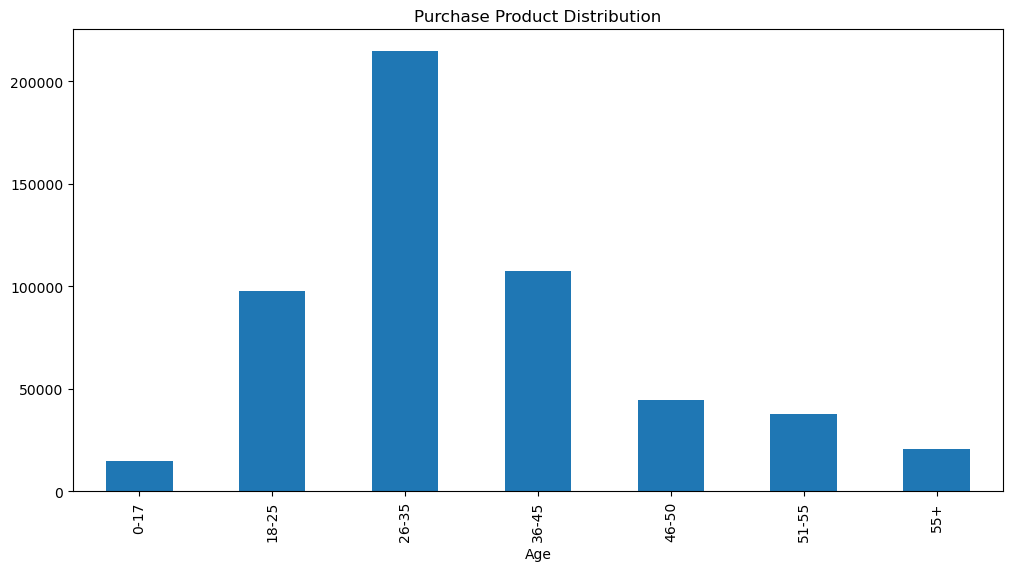

In [16]:
df.groupby("Age").size().plot(kind="bar", figsize=(12,6), title="Purchase Product Distribution")

In [17]:
lst=[]

for i in df["Age"].unique():
    lst.append([i,df[df["Age"]==i]["Product_ID"].nunique()])

data = pd.DataFrame(lst , columns=(['Age', 'Unique_Products']))
data

,Age,Unique_Products
0,0-17,2300
1,55+,2573
2,26-35,3419
3,46-50,3099
4,51-55,2877
5,36-45,3318
6,18-25,3213


<Axes: xlabel='Age'>

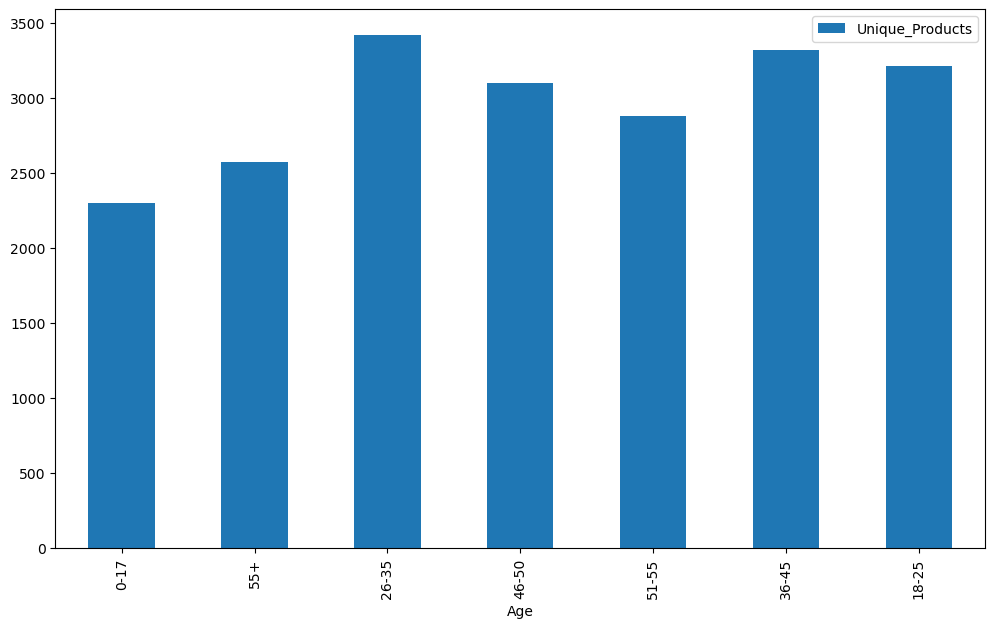

In [18]:
data.plot.bar(x="Age", figsize=(12,7))

#### Which Product is mostly buy of age his "Product_ID"

In [19]:
# Count how many times each product is bought per age
result = df.groupby(['Age', 'Product_ID']).size().reset_index(name='count')

# Get most bought product for each age group
result = result.loc[result.groupby('Age')['count'].idxmax()]

print(result.sort_values(by= "count",ascending=False))

         Age Product_ID  count
7919   26-35  P00265242    732
4583   18-25  P00265242    388
9165   36-45  P00025442    348
17338  51-55  P00265242    140
14406  46-50  P00265242    136
19999    55+  P00265242    104
1585    0-17  P00255842     64


#### give me total Purchases according to Age

In [20]:
df.groupby("Age")["Purchase"].sum()

Age
0-17      132659006
18-25     901669280
26-35    1999749106
36-45    1010649565
46-50     413418223
51-55     361908356
55+       197614842
Name: Purchase, dtype: int64

<Axes: title={'center': 'Total Puchase Amount Percentage According to its age '}, ylabel='Purchase'>

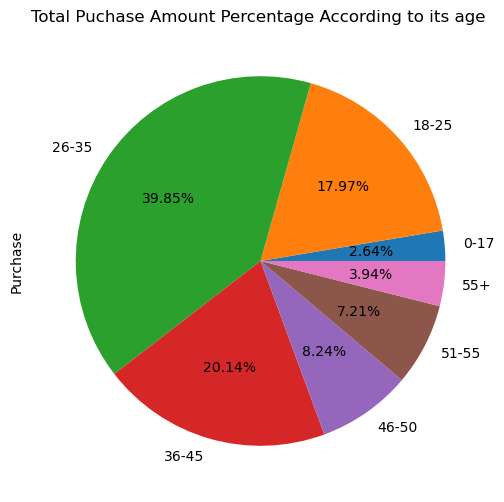

In [21]:
df.groupby("Age")["Purchase"].sum().plot.pie(autopct="%.2f%%" , figsize=(12,6) , title="Total Puchase Amount Percentage According to its age ")

<Axes: title={'center': 'Mean of Puchase Amount Percentage According to its age '}, ylabel='Purchase'>

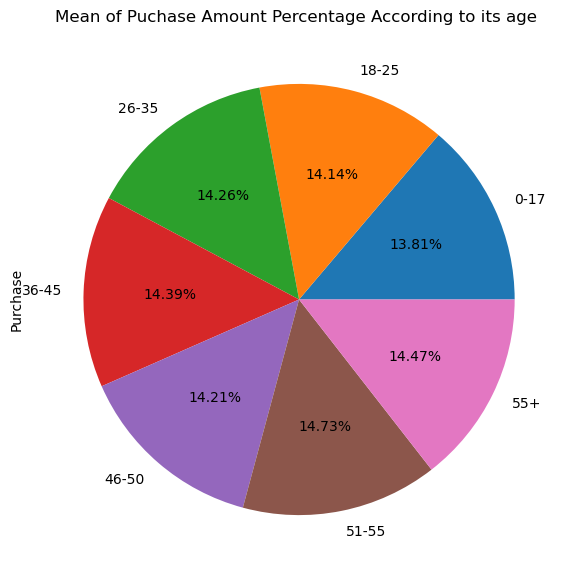

In [22]:
df.groupby("Age")["Purchase"].mean().plot.pie(autopct="%.2f%%" , figsize=(12,7) , title="Mean of Puchase Amount Percentage According to its age ")

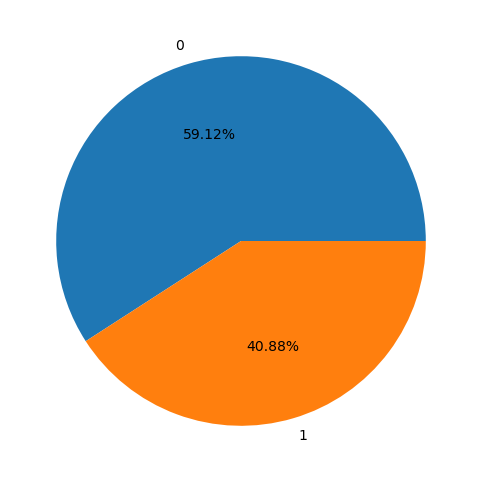

In [23]:
data = df.groupby('Marital_Status').size().plot(kind="pie", autopct="%.2f%%", figsize=(10,6))

<Axes: xlabel='Gender', ylabel='count'>

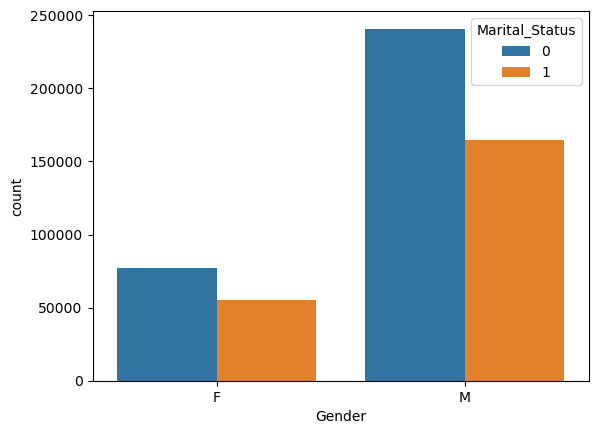

In [24]:
sns.countplot(data=df, x='Gender', hue='Marital_Status')


In [25]:
pd.crosstab(df["Gender"], df["Marital_Status"])

Marital_Status,0,1
Gender,,
F,76974,55223
M,240843,164537


#### Multicolumn Analysis 

<Axes: xlabel='Age', ylabel='count'>

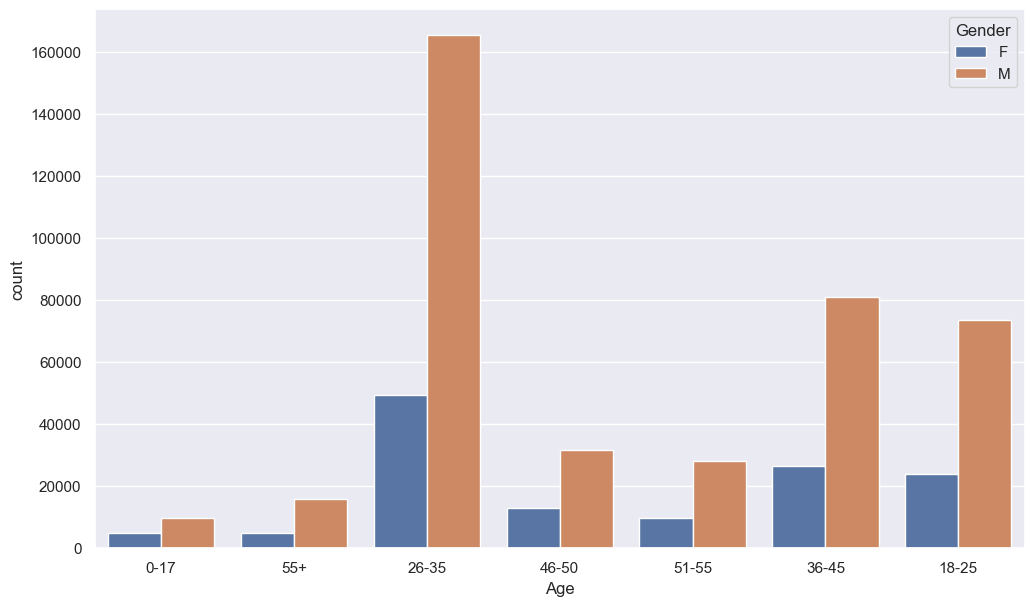

In [26]:
sns.set(rc={'figure.figsize':(12,7)})
sns.countplot(x="Age", hue="Gender", data=df)

<Axes: xlabel='Gender', ylabel='count'>

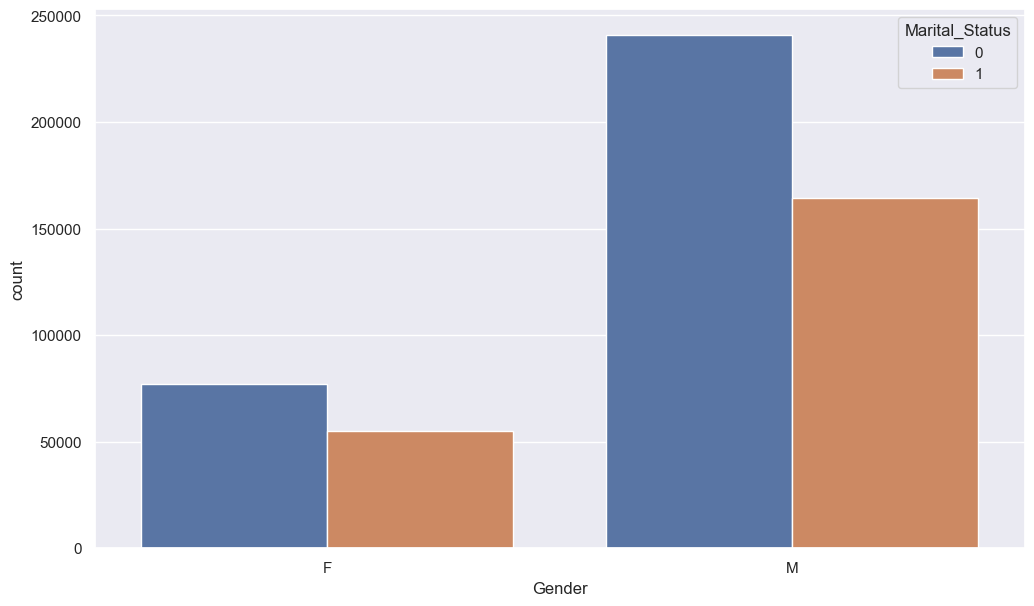

In [27]:
sns.set(rc={'figure.figsize':(12,7)})
sns.countplot(x="Gender", hue="Marital_Status", data=df)

In [28]:
df.nunique()

User_ID                        5891
Product_ID                     3623
Gender                            2
Age                               7
Occupation                       21
City_Category                     3
Stay_In_Current_City_Years        5
Marital_Status                    2
Product_Category_1               18
Purchase                      17959
dtype: int64

<Axes: xlabel='City_Category', ylabel='count'>

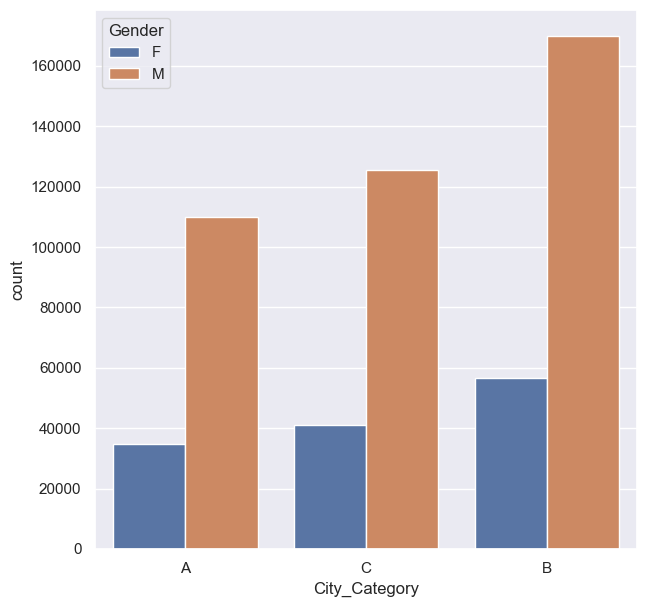

In [29]:
sns.set(rc={'figure.figsize':(7,7)})
sns.countplot(data=df, x="City_Category" , hue="Gender")

<Axes: xlabel='City_Category', ylabel='count'>

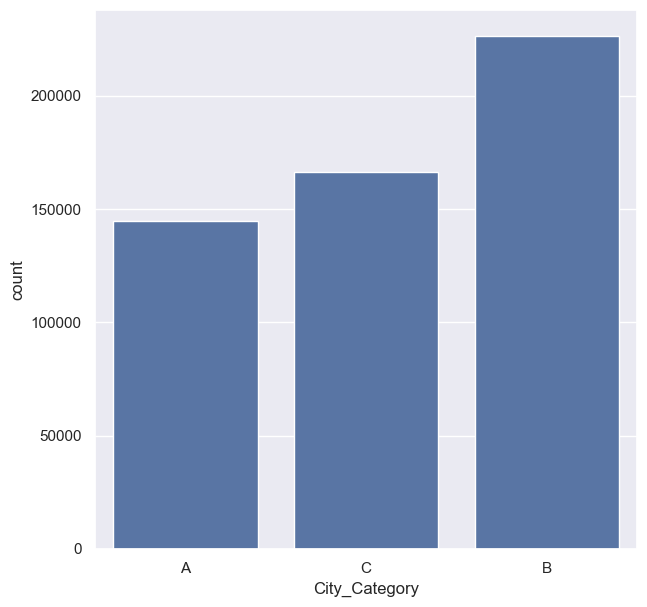

In [30]:
sns.countplot(data=df, x="City_Category" )

<Axes: xlabel='City_Category'>

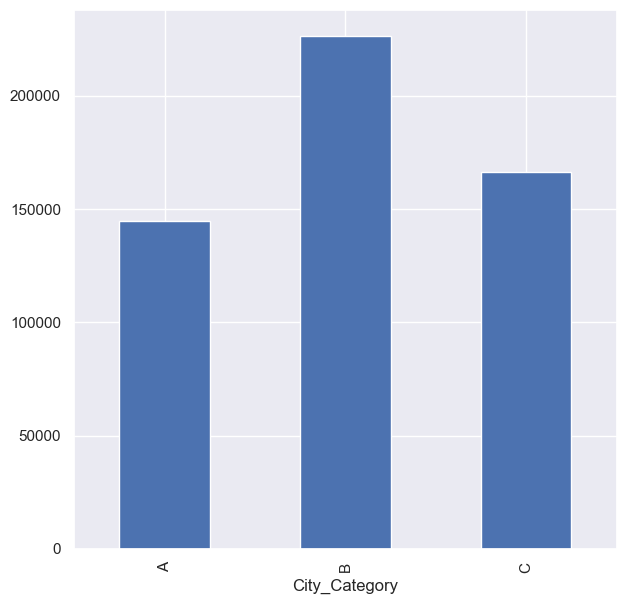

In [31]:
df.groupby("City_Category").size().plot(kind="bar")

<Axes: >

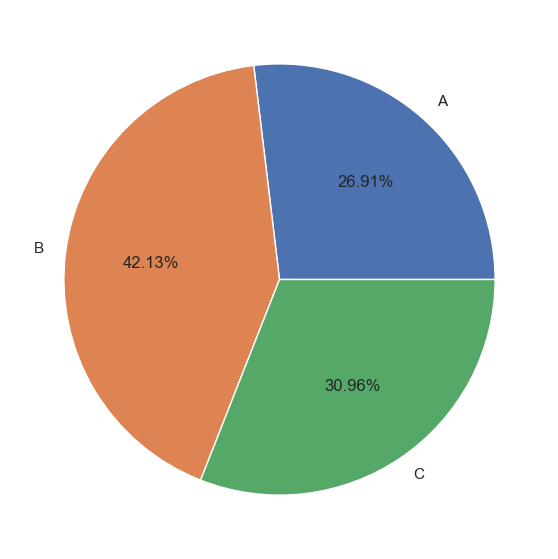

In [32]:
df.groupby("City_Category").size().plot(kind="pie", autopct="%.2f%%")

<Axes: xlabel='City_Category', ylabel='count'>

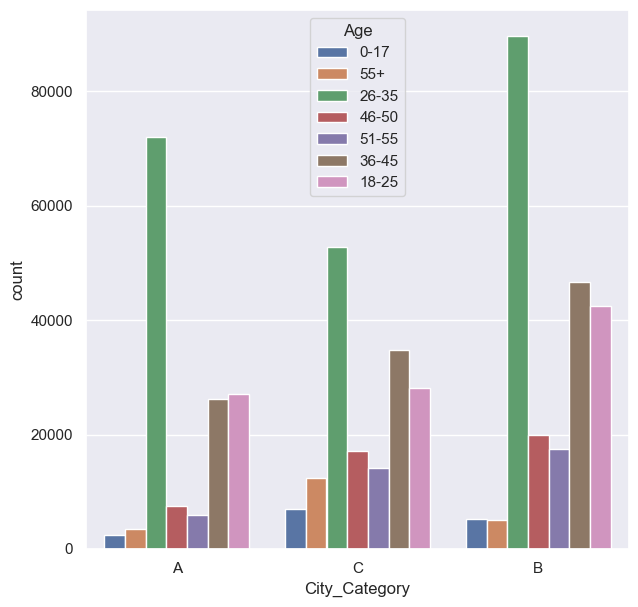

In [33]:
sns.countplot(data=df, x="City_Category", hue="Age")

<Axes: >

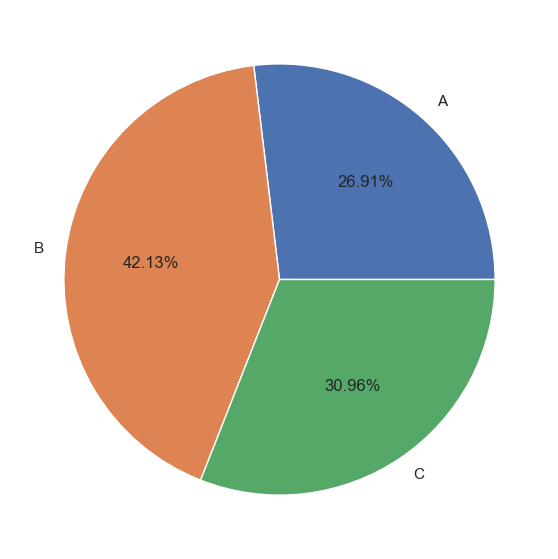

In [34]:
df.groupby("City_Category").size().plot(kind="pie", autopct="%.2f%%")

<Axes: ylabel='Purchase'>

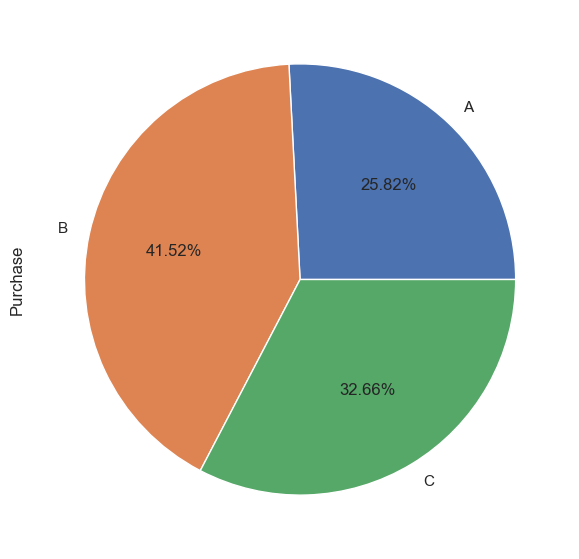

In [35]:
df.groupby("City_Category")["Purchase"].sum().plot(kind="pie", autopct="%.2f%%")

<Axes: ylabel='Purchase'>

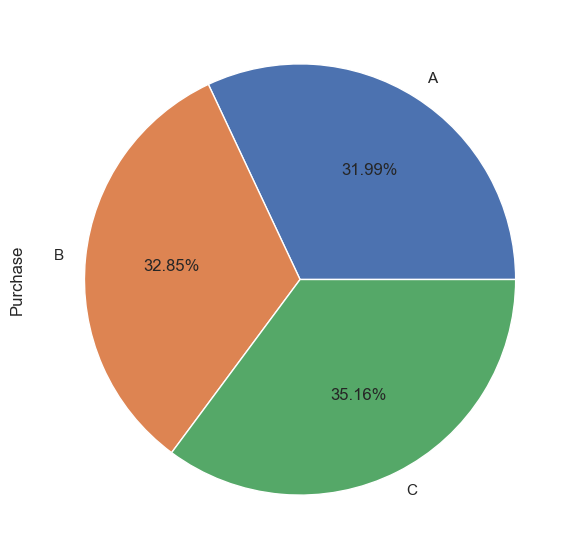

In [36]:
df.groupby("City_Category")["Purchase"].mean().plot(kind="pie", autopct="%.2f%%")

In [37]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
